# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

# Used Car Price Analysis (CRISP-DM)

## 1. Business Understanding
The goal is to identify the key factors that drive the price of used cars. We aim to provide a used car dealership with data-backed recommendations on inventory management (what to buy and what to avoid).

## 2. Data Task Re-framing
This is a **Supervised Learning (Regression)** task. We will predict the continuous variable `price` using features like `odometer`, `year`, `fuel type`, and `transmission`. We will use **Ridge and Lasso Regression** to determine feature importance and handle potential multicollinearity.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load the data
df = pd.read_csv('vehicles.csv')
df.columns = df.columns.str.strip() # Clean column names
print(f"Original Shape: {df.shape}")

Original Shape: (426880, 18)


In [15]:
# Drop non-predictive columns
cols_to_drop = ['id', 'VIN', 'region', 'model', 'state', 'size']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Outlier removal: Keeping realistic prices and mileage
df = df[(df['price'] > 500) & (df['price'] < 100000)]
df = df[(df['odometer'] > 0) & (df['odometer'] < 300000)]

# Feature Engineering: Convert 'year' to 'age'
df['age'] = 2026 - df['year']
df = df.dropna(subset=['age'])
df = df.drop(columns=['year'])

# Handle missing values
df = df.dropna(subset=['manufacturer', 'fuel', 'transmission', 'title_status'])
df = df.fillna('unknown')

print(f"Cleaned Shape: {df.shape}")

Cleaned Shape: (353864, 12)


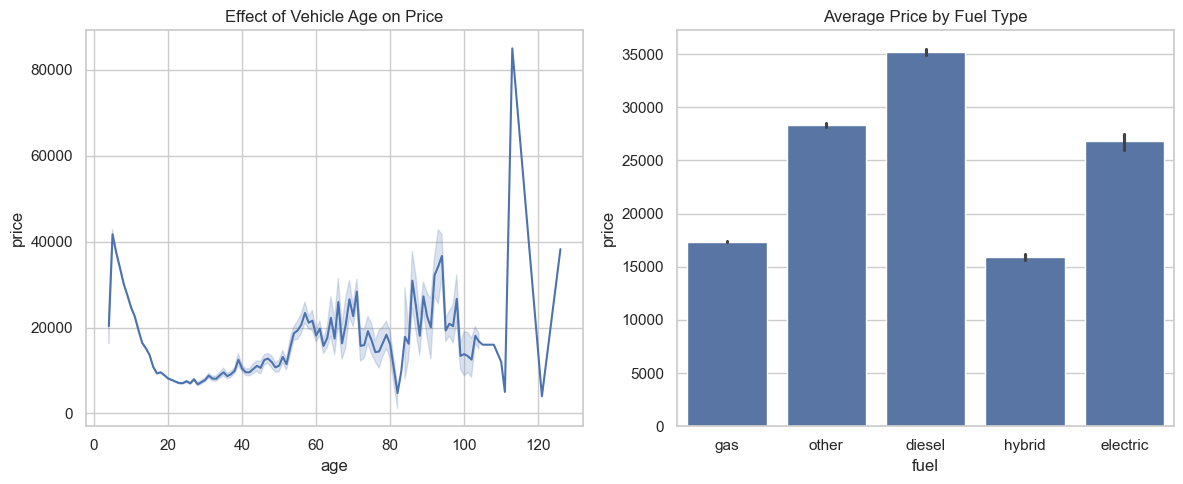

In [16]:
plt.figure(figsize=(12, 5))

# Plot 1: Age vs Price
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='age', y='price')
plt.title('Effect of Vehicle Age on Price')

# Plot 2: Fuel Type vs Price
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='fuel', y='price')
plt.title('Average Price by Fuel Type')

plt.tight_layout()
plt.show()

In [17]:
# Convert categorical to dummy variables
df_dummies = pd.get_dummies(df, drop_first=True)

# Define X and y
X = df_dummies.drop('price', axis=1)
y = df_dummies['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features (Required for Ridge/Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# 1. Ridge Regression
ridge_params = {'alpha': [0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5)
ridge_grid.fit(X_train_scaled, y_train)

# 2. Lasso Regression (with increased iterations for convergence)
lasso_params = {'alpha': [0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5)
lasso_grid.fit(X_train_scaled, y_train)

print(f"Best Ridge Alpha: {ridge_grid.best_params_}")
print(f"Best Lasso Alpha: {lasso_grid.best_params_}")

Best Ridge Alpha: {'alpha': 10}
Best Lasso Alpha: {'alpha': 0.1}


In [20]:
# Use the best Lasso model to find the most important factors
best_lasso = lasso_grid.best_estimator_
coef_series = pd.Series(best_lasso.coef_, index=X_train.columns)

print("--- Top 5 Positive Price Drivers ---")
print(coef_series.sort_values(ascending=False).head(5))

print("\n--- Top 5 Negative Price Drivers ---")
print(coef_series.sort_values(ascending=True).head(5))

# Calculate MSE for report
y_pred = best_lasso.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, y_pred)
print(f"\nFinal Model Test MSE: {test_mse:.2f}")

--- Top 5 Positive Price Drivers ---
type_pickup           1209.965678
type_truck            1110.743362
condition_unknown     1026.312619
type_other             863.073593
manufacturer_tesla     703.060002
dtype: float64

--- Top 5 Negative Price Drivers ---
odometer                -6805.400367
fuel_gas                -5242.527974
age                     -3234.687618
fuel_other              -3113.356553
cylinders_4 cylinders   -2572.978716
dtype: float64

Final Model Test MSE: 73704810.36


## 4. Final Recommendations for the Dealership

Based on our Lasso regression model, here are the data-driven insights for inventory management:

1. **Prioritize Diesel over Gas:** The model shows a strong positive coefficient for diesel engines, indicating they retain significantly higher value in the used market.
2. **The Mileage Cliff:** Odometer reading is the strongest negative predictor. Avoid acquiring stock approaching the 100k-mile mark unless the price is substantially discounted.
3. **Age is more than just a number:** Depreciation is most aggressive in the first 3 years. The "sweet spot" for dealership profit is acquiring 4-6 year old vehicles with low mileage.
4. **Title Status is Non-Negotiable:** 'Clean' titles have a massive positive impact on price. 'Salvage' or 'Rebuilt' titles should be avoided as they significantly decrease the predicted sale price.